# Visualisation des masques et des images ensembles

In [1]:
# Importations
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# 1. Demander l'ID et charger les fichiers
image_id = 2
img_path = f"../data/YOLO/images/0004652_11.23.44_356868_2019.jpg"
mask_path = f"../data/YOLO/labels/0004652_11.23.44_356868_2019.txt"

# 2. Charger l'image
img = cv2.imread(img_path)
# Convertir l'image de BGR (OpenCV) à RGB (Matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

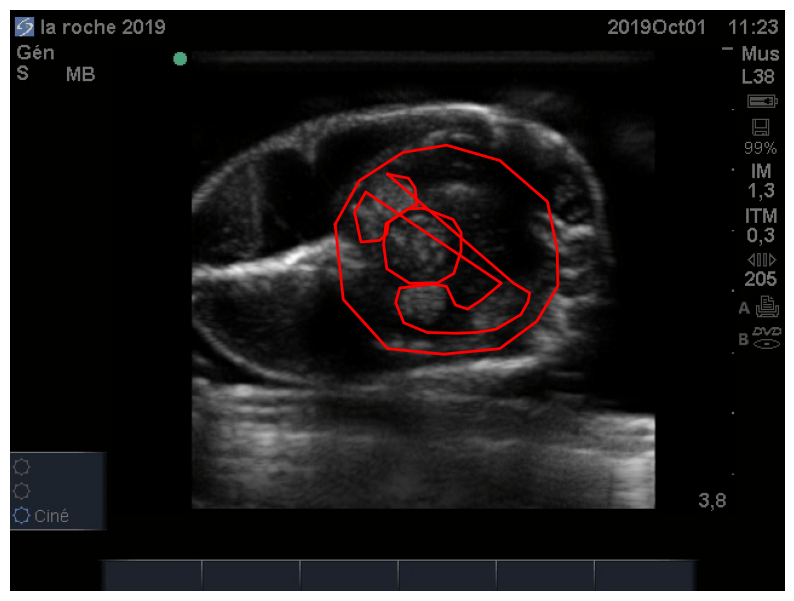

In [3]:
# 3. Afficher l'image et le masque avec Matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis('off')

# 4. Lire le masque
try:
    with open(mask_path, 'r') as f:
        for line in f:
            parts = list(map(float, line.split()))
            class_id = int(parts[0])
            points = parts[1:]

            # Convertir les points en paires (x, y)
            polygon = [(x, y) for x, y in zip(points[::2], points[1::2])]

            # Si les points sont normalisés (0-1), les convertir en pixels
            if all(0 <= x <= 1 and 0 <= y <= 1 for x, y in polygon):
                polygon = [(x * img.shape[1], y * img.shape[0]) for x, y in polygon]

            # Fermer le polygone (ajouter le premier point à la fin)
            polygon.append(polygon[0])

            # Extraire les coordonnées x et y pour Matplotlib
            x_coords = [p[0] for p in polygon]
            y_coords = [p[1] for p in polygon]

            # Dessiner le polygone
            plt.plot(x_coords, y_coords, color='red', linewidth=2)

except Exception as e:
    print(f"❌ Erreur dans {mask_path} : {e}")
    exit()



plt.show()